# Preparing workspace

In [1]:
# download model checkpoint from google drive drive and move it to checkpoints folder

#!gdown 'https://drive.google.com/uc?id=10QQT131P5jJ6s0PQ7o-xZM3MYAzc6FDR' -O sam_vit_l_0b3195.pth

# install necessary modules
import sys

!{sys.executable} -m pip install mediapipe
!{sys.executable} -m pip install torch opencv-python Pillow
!{sys.executable} -m pip install git+https://github.com/openai/CLIP.git
!{sys.executable} -m pip install git+https://github.com/facebookresearch/segment-anything.git


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-9ve3u9qs
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-9ve3u9qs
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-cnggur4q
  Running command git clone --filter=blob:none --quiet https://github.com/faceboo

In [2]:
# necessary imports

import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import clip
import torch
import numpy as np
import helper as h
import math
import mediapipe as mp

In [4]:
# load and preconfigure necessary models


# load SAM

sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#sam_checkpoint = "../checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint = "../../glasses preparation/checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

#default
device = "cpu"

#NVIDIA
#device = "cuda"

#M1 chips
#device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)


# Load CLIP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)


# Initialize MediaPipe Face Mesh

mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True)

/Users/andriimatsevytyi/anaconda3/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)
I0

W0000 00:00:1723459120.374724 8610396 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1723459120.377189 8610396 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


# Helper functions that require models

In [24]:
# wrapping into he function
def process_glasses_with_SAM_and_NLP(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(image)
    
    image = Image.open(image_path)
    cropped_boxes = []

    for mask in masks:
        cropped_boxes.append(h.segment_image(image, mask["segmentation"]).crop(h.convert_box_xywh_to_xyxy(mask["bbox"])))
        
        
    positive_texts = ["side arms", "temple arms"]
    negative_texts = ["top bar"]
    scores = retriev(cropped_boxes, positive_texts, negative_texts)
    indices = get_indices_of_values_above_threshold(scores, 0.05)
    
    segmentation_masks = []

    for seg_idx in indices:
        segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
        segmentation_masks.append(segmentation_mask_image)
        

    combined_mask = Image.new('L', image.size, 0)
    for mask in segmentation_masks:
        combined_mask.paste(mask, (0, 0), mask)
    
    # Make the selected region transparent by modifying the alpha channel
    image_rgba = image.convert('RGBA')
    np_image = np.array(image_rgba)
    np_mask = np.array(combined_mask)

    # Set the alpha channel to 0 for the selected region
    np_image[:, :, 3] = np.where(np_mask == 255, 0, np_image[:, :, 3])

    # Convert back to Image
    result_image = Image.fromarray(np_image)
    
    # Display the final image
    plt.figure(figsize=(20, 20))
    plt.imshow(result_image, cmap='gray')
    plt.axis('off')
    plt.show()
    
    
    # Computing necessary fitting features
    
    scores = retriev_back(cropped_boxes, "top bridge") #top bar for the bridge itself
    indices = get_indices_of_values_above_threshold(scores, 0.05)

    segmentation_masks = []

    for seg_idx in indices:
        segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
        segmentation_masks.append(segmentation_mask_image)

    original_image = Image.open(image_path)

    image_width, image_height = original_image.size
    image_center = (image_width / 2, image_height / 2)

    # finding central mask
    min_distance = float('inf')
    most_central_mask = None

    for mask in segmentation_masks:
        centroid = h.calculate_centroid(mask)
        distance_to_center = h.calculate_distance(centroid, image_center)
        if distance_to_center < min_distance:
            min_distance = distance_to_center
            most_central_mask = mask
    
            
    img = np.array(original_image)

    # pick center of the glasses and necessary points that will be used in fitting
    mask_center = int(h.calculate_centroid(most_central_mask)[0])
            
    lower_point = (mask_center, np.min(np.argwhere(np.array(most_central_mask) > 0)[:, 0]))
    non_transparent_indices = np.argwhere(img[:lower_point[1], mask_center] == 0)

    if non_transparent_indices.size > 0:
        higher_point = (mask_center, np.max(non_transparent_indices))
    else:
        # Handle the case when no transparent point is found
        higher_point = (mask_center, lower_point[1] - 5) 
        
    return result_image, lower_point, higher_point

def get_facial_landmarks(image):
    height, width, _ = image.shape
    results = face_mesh.process(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

    if not results.multi_face_landmarks:
        return None

    landmarks = results.multi_face_landmarks[0]
    return [(int(point.x * width), int(point.y * height)) for point in landmarks.landmark]


@torch.no_grad()
def retriev(elements: list[Image.Image], positive_texts: list[str], negative_texts: list[str]) -> torch.Tensor:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_positive_texts = clip.tokenize(positive_texts).to(device)
    tokenized_negative_texts = clip.tokenize(negative_texts).to(device)
    
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    positive_text_features = model.encode_text(tokenized_positive_texts)
    negative_text_features = model.encode_text(tokenized_negative_texts)
    
    image_features /= image_features.norm(dim=-1, keepdim=True)
    positive_text_features /= positive_text_features.norm(dim=-1, keepdim=True)
    negative_text_features /= negative_text_features.norm(dim=-1, keepdim=True)
    
    positive_probs = 100. * image_features @ positive_text_features.T
    negative_probs = 100. * image_features @ negative_text_features.T
    
    avg_positive_probs = positive_probs.mean(dim=1)
    avg_negative_probs = negative_probs.mean(dim=1)
    
    final_probs = avg_positive_probs - avg_negative_probs
    
    return final_probs.softmax(dim=0)

@torch.no_grad()
def retriev_back(elements: list[Image.Image], search_text: str) -> int:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_text = clip.tokenize([search_text]).to(device)
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    text_features = model.encode_text(tokenized_text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    probs = 100. * image_features @ text_features.T
    return probs[:, 0].softmax(dim=0)


def get_indices_of_values_above_threshold(scores, threshold):
    return torch.nonzero(scores > threshold).squeeze().tolist()


# End-to-end function itself

In [25]:
def put_glasses(face_image_path, glasses_image_path, glasses_article, act_bridge, glasses_preprocessed=False):

    face_image = cv2.imread(face_image_path)
    
    if glasses_preprocessed:
        #extract saved data from the fiile/database
        glasses_image = cv2.imread(glasses_image_path, cv2.IMREAD_UNCHANGED)  # Load with alpha channel
        lower_bridge, higher_bridge = (0, 0) # - load from file
        True
    else:
        #call process_with_NLP
        glasses_image, lower_bridge, higher_bridge = process_glasses_with_SAM_and_NLP(glasses_image_path)
        glasses_image = np.array(glasses_image)
        True

    # Detect facial landmarks

    face_landmarks = get_facial_landmarks(face_image)
    if not face_landmarks:
        raise Exception("No face detected in the image")

        
    # Define the landmarks of interest
    landmarks_of_interest = [6, 8, 168, 162, 193, 417, 389]  # Nose bridge, left ear area, right ear area
    
    nose_bridge = (face_landmarks[168][0], face_landmarks[168][1])
    above_nose_bridge = (face_landmarks[8][0], face_landmarks[8][1])
    below_nose_bridge = (face_landmarks[6][0], face_landmarks[6][1])

    # Extract relevant landmarks
    left_face_width = face_landmarks[234]
    right_face_width = face_landmarks[454]

    # Calculate the glasses' width and height
    glasses_width = np.linalg.norm(np.array(right_face_width) - np.array(left_face_width))
    glasses_height = int(glasses_width * (glasses_image.shape[0] / glasses_image.shape[1]))

    # finding face totation (roll axis) angle clockwise in radians
    # will be useful when rotating glasses to align with face
    # formula is arctan { (left_landmark.y - right_landmark.y) / (right_landmark.x - left_landmark.x)) }

    rot_angle = math.atan((face_landmarks[162][1] - face_landmarks[389][1])/(face_landmarks[389][0] - face_landmarks[162][0]))
    print("clockwise rotation angle: ", rot_angle)

    # finding actual face width
    # will be useful when scaling glasses to necessary width
    # formula is sqrt(∂y^2 + ∂x^2)

    dp_face_width = math.sqrt((face_landmarks[162][1] - face_landmarks[389][1])**2 + (face_landmarks[389][0] - face_landmarks[162][0])**2)
    print("actual face width: ", dp_face_width)

    # formula for scaling glasses in accordance to their width and face width. Now they are scaled to match the face
    # measure your nose bridge (it is the edge of the nose usually located between inside eye tips)
    # glasses width = dp face width / dp bridge length * actual bridge length * full glasses width / bridge glasses length
    dp_face_bridge = face_landmarks[417][0] - face_landmarks[193][0]

    glasses_bridge, full_width = h.load_from_xls('../assets/All_glasses_2_1096.xlsx', ['Eyewear - Bridge width', 'Eyewear - Frame width'], name=glasses_article)
    new_glasses_width = dp_face_width / dp_face_bridge * act_bridge / math.sqrt(2) / full_width * glasses_width

    # cases depending on bridge vs top bar on glasses (https://www.clearly.com.au/thelook/wp-content/uploads/2014/07/Blog.jpg)

    # Resize glasses image
    glasses_resized = cv2.resize(glasses_image, (int(new_glasses_width), int(glasses_height*new_glasses_width/glasses_width)), interpolation=cv2.INTER_AREA)

    # coordinates of nose bridge on glasses
    # calculated in another notebook (when removing temples)
    higher_bridge = (760, 612)
    lower_bridge = (750, 630)

    # Rotate glasses image
    M = cv2.getRotationMatrix2D((glasses_resized.shape[1] // 2, glasses_resized.shape[0] // 2), rot_angle * 180 / math.pi, 1)
    glasses_rotated = cv2.warpAffine(glasses_resized, M, (glasses_resized.shape[1], glasses_resized.shape[0]), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)

    if abs(act_bridge - glasses_bridge) < 3:
        # default case
        converted_coords = (int(lower_bridge[0] / glasses_image.shape[0] * glasses_rotated.shape[0]), int(lower_bridge[1] / glasses_image.shape[1] * glasses_rotated.shape[1]))
        top_left = (nose_bridge[0] - converted_coords[0], nose_bridge[1] - converted_coords[1])
    elif act_bridge > glasses_bridge:
        # face nose bridge is too big
        converted_coords = (int((higher_bridge[0]+lower_bridge[0]) / 2 / glasses_image.shape[0] * glasses_rotated.shape[0]), int((higher_bridge[1]+lower_bridge[1]) / 2 / glasses_image.shape[1] * glasses_rotated.shape[1]))
        top_left = (above_nose_bridge[0] - converted_coords[0], above_nose_bridge[1] - converted_coords[1])
    else:
        # face nose bridge is too small (pick one level lower)
        converted_coords = (int(lower_bridge[0] / glasses_image.shape[0] * glasses_rotated.shape[0]), int(lower_bridge[1] / glasses_image.shape[1] * glasses_rotated.shape[1]))
        top_left = (below_nose_bridge[0] - converted_coords[0], below_nose_bridge[1] - converted_coords[1])

    print(glasses_image.shape, "=>", glasses_rotated.shape)

    print(higher_bridge, "=>", converted_coords)

    # Overlay glasses on face image
    overlay_image = face_image.copy()
    for i in range(glasses_rotated.shape[0]):
        for j in range(glasses_rotated.shape[1]):
            if glasses_rotated[i, j, 3] > 0:  # Alpha channel check
                y, x = top_left[1] + i, top_left[0] + j
                if 0 <= y < overlay_image.shape[0] and 0 <= x < overlay_image.shape[1]:
                    overlay_image[y, x] = glasses_rotated[i, j, :3]

    # Display the final image
    plt.figure(figsize=(20, 20))
    plt.imshow(overlay_image, cmap='gray')
    plt.axis('off')
    plt.show()
    
    return overlay_image


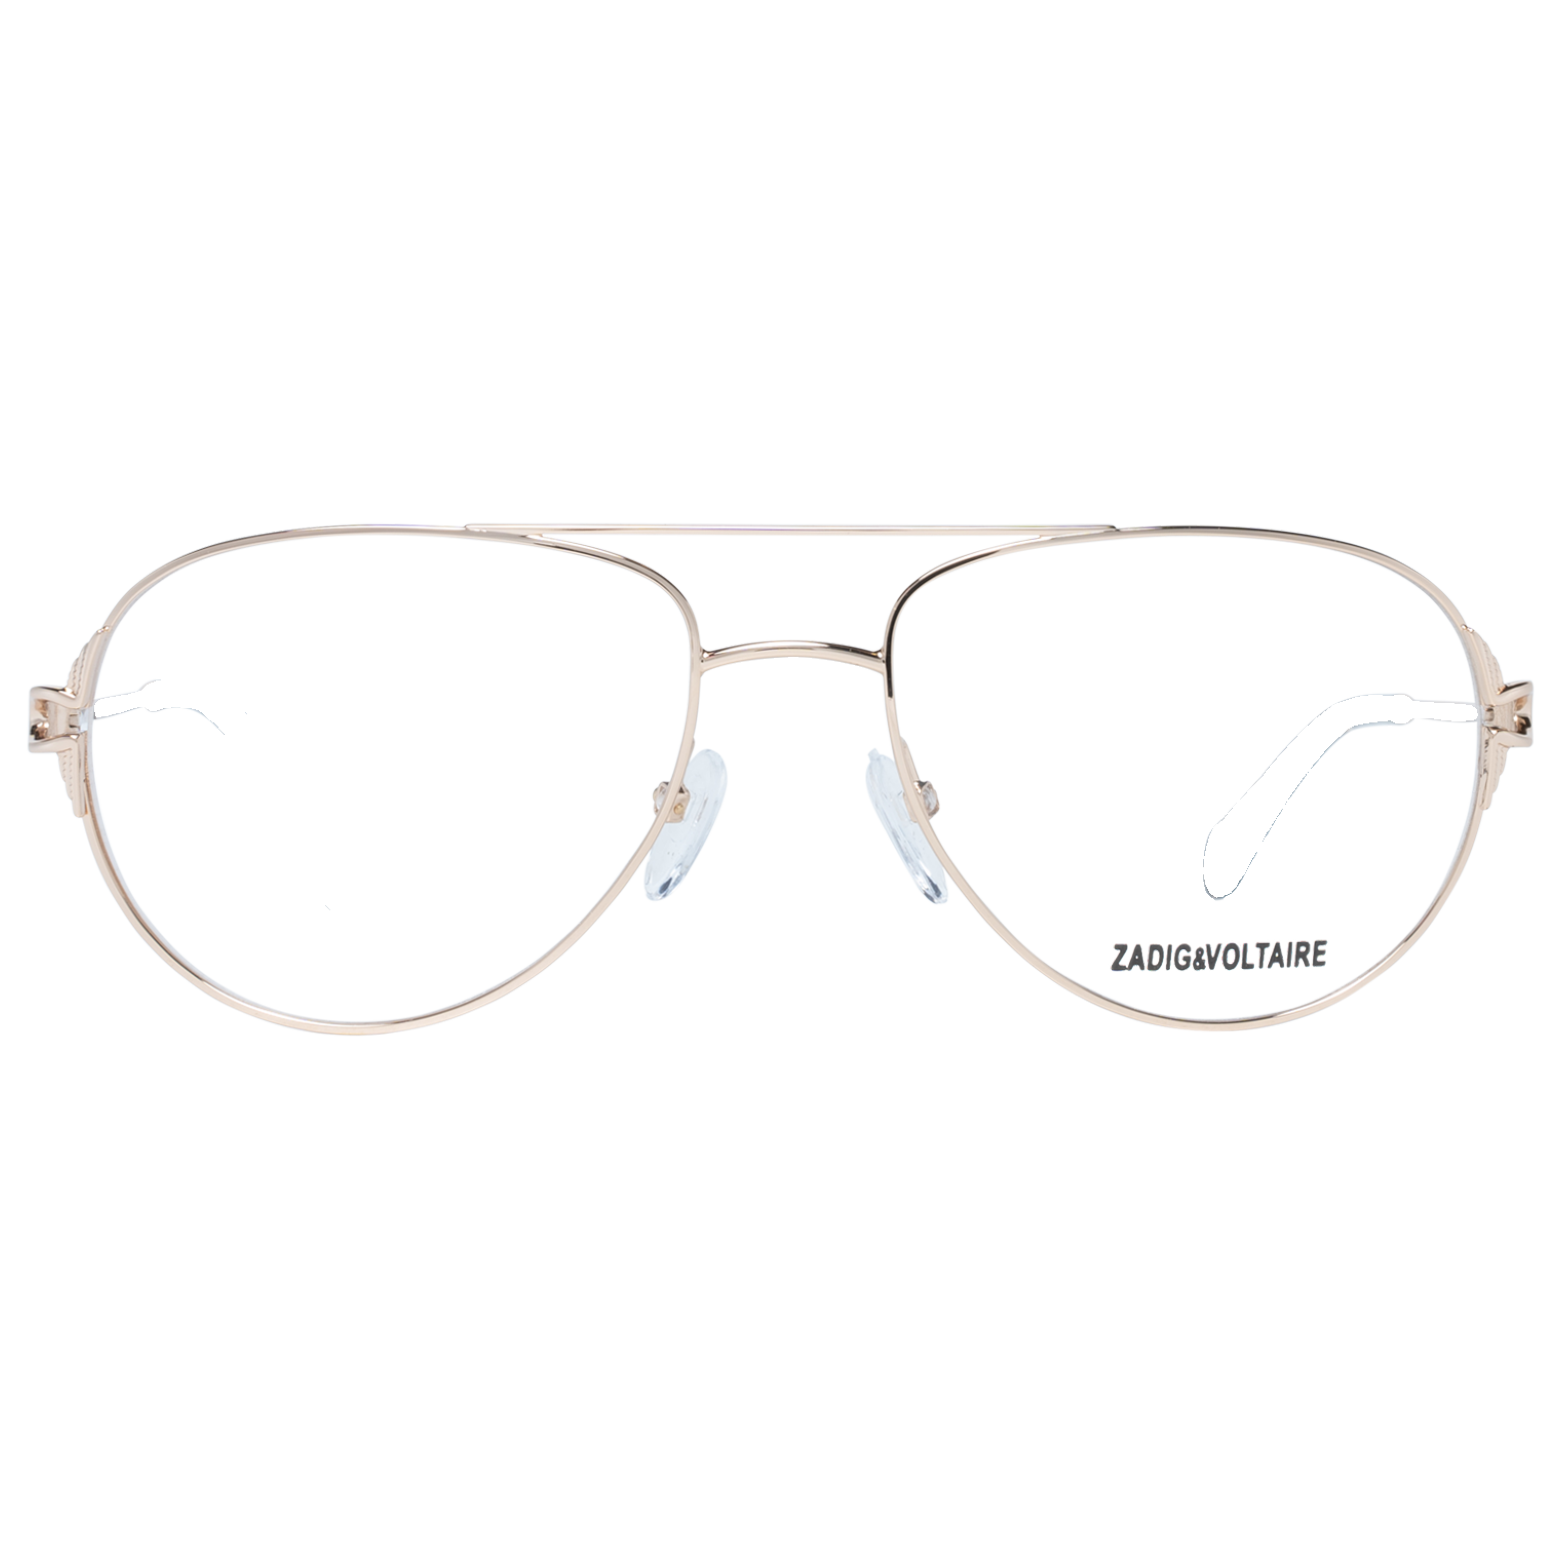

/Users/andriimatsevytyi/anaconda3/lib/python3.10/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


clockwise rotation angle:  -0.05515871592817881
actual face width:  489.74483151943525
(1500, 1500, 4) => (544, 545, 4)
(760, 612) => (273, 225)


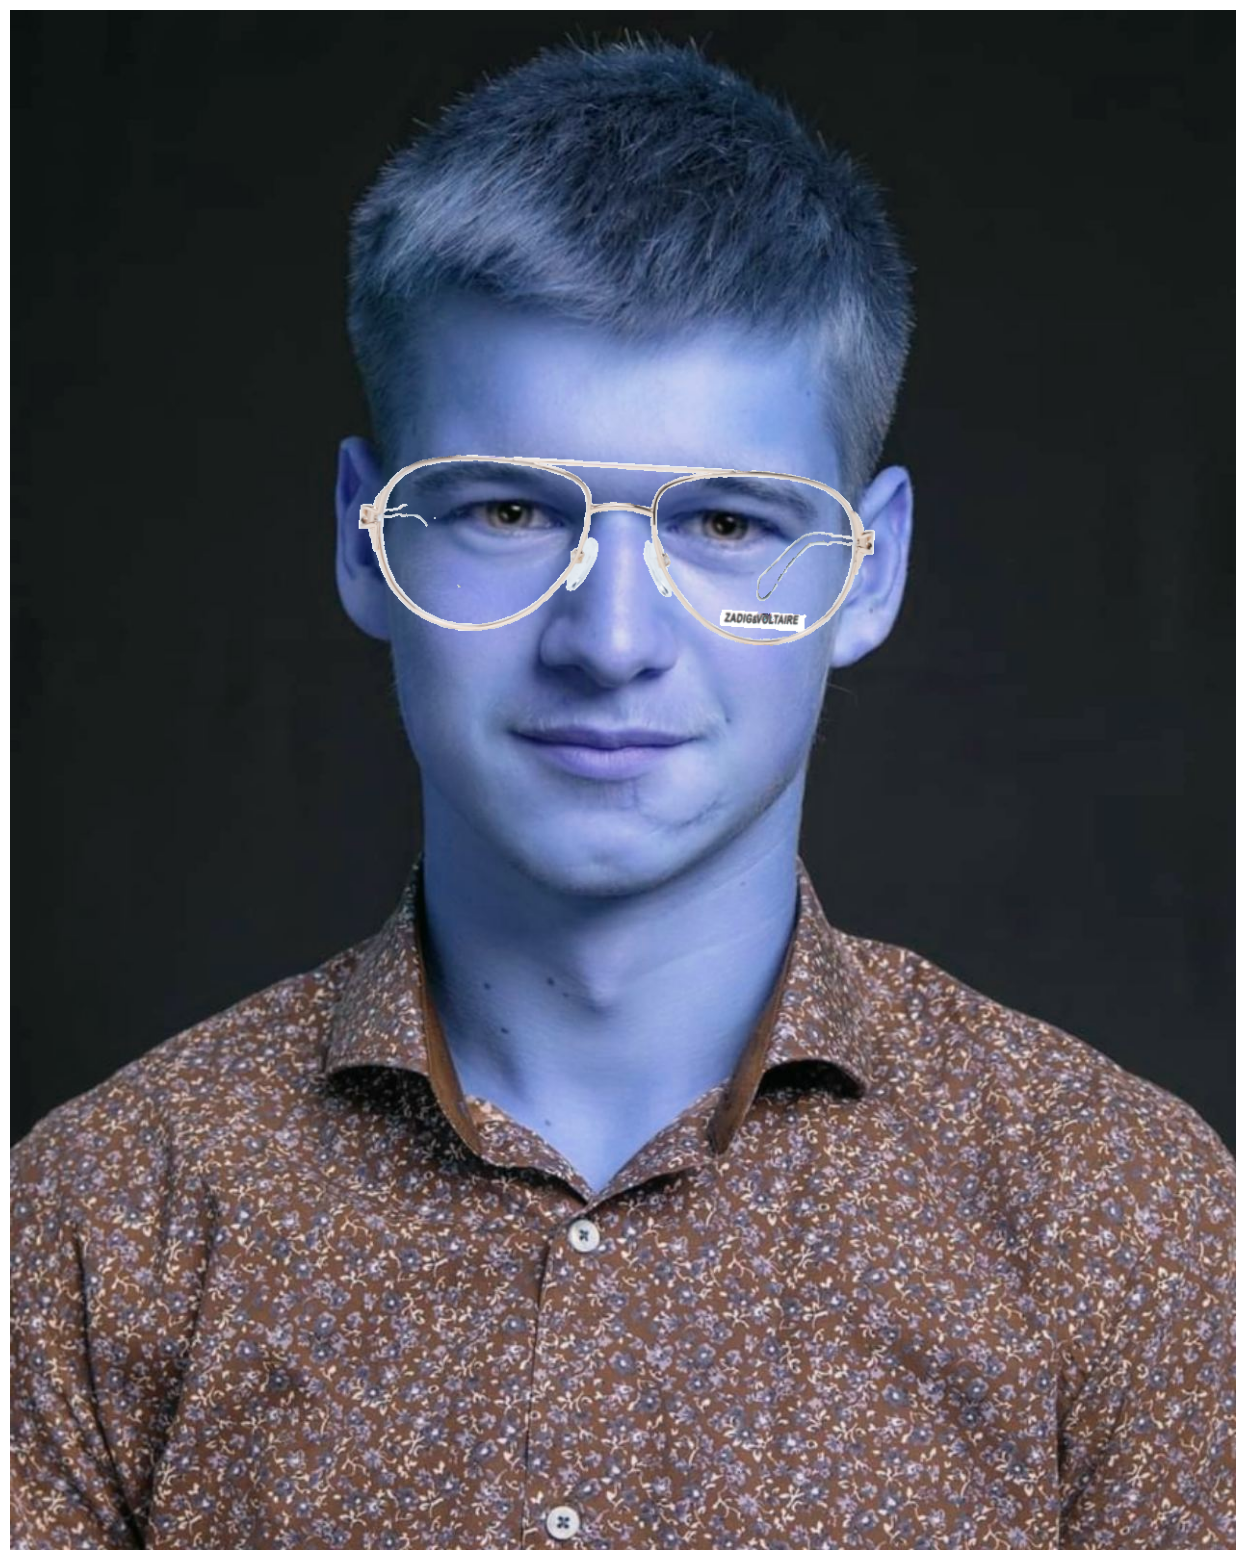

array([[[ 11,  17,  16],
        [ 11,  17,  16],
        [ 11,  17,  16],
        ...,
        [ 15,  21,  20],
        [ 15,  21,  20],
        [ 15,  21,  20]],

       [[ 11,  17,  16],
        [ 11,  17,  16],
        [ 11,  17,  16],
        ...,
        [ 15,  21,  20],
        [ 15,  21,  20],
        [ 15,  21,  20]],

       [[ 11,  17,  16],
        [ 11,  17,  16],
        [ 11,  17,  16],
        ...,
        [ 15,  21,  20],
        [ 15,  21,  20],
        [ 15,  21,  20]],

       ...,

       [[ 98,  76,  81],
        [100,  78,  83],
        [113,  92, 100],
        ...,
        [112,  76,  70],
        [112,  78,  72],
        [112,  78,  72]],

       [[133, 112, 115],
        [135, 113, 118],
        [146, 125, 133],
        ...,
        [114,  78,  70],
        [113,  80,  71],
        [111,  78,  69]],

       [[163, 142, 145],
        [161, 142, 145],
        [168, 147, 155],
        ...,
        [114,  78,  70],
        [114,  78,  70],
        [109,  76,  67]]

In [29]:
# Example usage
face_path = '../faces/0.jpg'
glasses_path = '../../glasses preparation/images/190605154458_01.png'
glasses_article = '190605154458'
nose_bridge_width = 23.5 # measure your nose brige
result = put_glasses(face_path, glasses_path, glasses_article, nose_bridge_width, False)
result